# Importing Necessary Libraries

In [ ]:
import pandas as pd
import numpy as np
import pickle, gzip
from sklearn import svm
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, confusion_matrix, PrecisionRecallDisplay, accuracy_score, matthews_corrcoef, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import math
from google.colab import files
uploaded = files.upload()
!apt-get install -y fonts-liberation

Saving training_df.tsv to training_df.tsv
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-liberation is already the newest version (1:1.07.4-11).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.


# Functions

## Feature Extraction

In [ ]:
def sequence_composition(sequence:str) -> np.ndarray[np.float64]:
  sequence = sequence[:40]
  alphabet = "AQLSREKTNGMWDHFYCIPV"
  composition_matrix = np.zeros((20,40))
  composition_vector = np.zeros((20))
  for i in range(len(alphabet)):
    for j in range(len(sequence)):
      if alphabet[i] == sequence[j]:
        composition_matrix[i][j] += 1
        composition_vector[i] += composition_matrix[i][j]
  composition_vector = composition_vector/40
  return composition_vector

def hp_ai(sequence:str, window_size:int = 6 ) -> np.ndarray[np.float64]:
  kd_scale = {
    'R': -4.5,  # Arg
    'K': -3.9,  # Lys
    'N': -3.5,  # Asn
    'D': -3.5,  # Asp
    'Q': -3.5,  # Gln
    'E': -3.5,  # Glu
    'H': -3.2,  # His
    'P': -1.6,  # Pro
    'Y': -1.3,  # Tyr
    'W': -0.9,  # Trp
    'S': -0.8,  # Ser
    'T': -0.7,  # Thr
    'G': -0.4,  # Gly
    'A':  1.8,  # Ala
    'M':  1.9,  # Met
    'C':  2.5,  # Cys
    'F':  2.8,  # Phe
    'L':  3.8,  # Leu
    'V':  4.2,  # Val
    'I':  4.5   # Ile
    }

  a = 2.9 # relative volume of valine
  b = 3.9 # relative volume leucine/isoleucine

  sequence = sequence[:40]
  # padding to have as many scores as residues  (each window refers to the central res)
  d = int(window_size/2)
  sequence = "X"*d + sequence + "X"*d #padding
  hydrophobicities = np.array([])
  AIs = np.array([])  #aliphatic indexes
  for i in range(len(sequence)-(window_size)+1):
      counts_A = 0
      counts_V = 0
      counts_I = 0
      counts_L = 0
      hydrophobicity_score = 0
      window = sequence[i:i+window_size]
      for j in range(window_size):
        if window[j] != "X":
          hydrophobicity_score = (hydrophobicity_score + kd_scale[window[j]])
          if window[j] == 'A':
              counts_A += 1
          elif window[j] == 'V':
              counts_V += 1
          elif window[j] == 'I':
              counts_I += 1
          elif window[j] == 'L':
                counts_L += 1
      X_A = (counts_A / window_size)
      X_V = (counts_V / window_size)
      X_I = (counts_I / window_size)
      X_L = (counts_L / window_size)
      AI = X_A + a * X_V + b * (X_I + X_L) #Aliphatic Index Formula
      hydrophobicities = np.append(hydrophobicities, hydrophobicity_score / window_size)
      AIs = np.append(AIs, AI)
  H_AI = np.array([hydrophobicities.mean(), hydrophobicities.max(), np.argmax(hydrophobicities), AIs.mean(), AIs.max(), np.argmax(AIs)])
  return H_AI  #hydrophobicity and aliphatic index alltogether

def SSE(sequence,window_size):
  alpha_helix_scale = {
      "G": 0.570,  # Gly
      "P": 0.570,  # Pro
      "Y": 0.690,  # Tyr
      "C": 0.700,  # Cys
      "S": 0.770,  # Ser
      "T": 0.830,  # Thr
      "N": 0.670,  # Asn
      "R": 0.980,  # Arg
      "H": 1.000,  # His
      "D": 1.010,  # Asp
      "I": 1.080,  # Ile
      "W": 1.080,  # Trp
      "Q": 1.110,  # Gln
      "F": 1.130,  # Phe
      "K": 1.160,  # Lys
      "V": 1.060,  # Val
      "L": 1.210,  # Leu
      "A": 1.420,  # Ala
      "M": 1.450,  # Met
      "E": 1.510   # Glu
  }
  beta_sheet_scale = {
      "E": 0.370,  # Glu
      "D": 0.540,  # Asp
      "P": 0.550,  # Pro
      "G": 0.750,  # Gly
      "S": 0.750,  # Ser
      "K": 0.740,  # Lys
      "H": 0.870,  # His
      "N": 0.890,  # Asn
      "R": 0.930,  # Arg
      "A": 0.830,  # Ala
      "M": 1.050,  # Met
      "Q": 1.100,  # Gln
      "C": 1.190,  # Cys
      "T": 1.190,  # Thr
      "L": 1.300,  # Leu
      "F": 1.380,  # Phe
      "W": 1.370,  # Trp
      "Y": 1.470,  # Tyr
      "I": 1.600,  # Ile
      "V": 1.700   # Val
  }
  sequence = sequence[:40]
  # padding to have as many scores as residues (each window refers to the central res)
  d = int(window_size/2)
  sequence = "X"*d + sequence + "X"*d #padding
  alpha_helix = np.array([])
  beta_sheet = np.array([])
  for i in range(len(sequence)-(window_size)+1):
      alpha_score = 0
      beta_score = 0
      window = sequence[i:i+window_size]
      for j in range(window_size):
        w = 1 - abs(j - (window_size - 1)/2) / ((window_size - 1)/2)
        if window[j] != "X":
          alpha_score = alpha_score + w * alpha_helix_scale[window[j]]
          beta_score = beta_score + w * beta_sheet_scale[window[j]]
      alpha_helix = np.append(alpha_helix, alpha_score / window_size)
      beta_sheet = np.append(beta_sheet, beta_score / window_size)
  alpha_feature = np.array([alpha_helix.mean(), alpha_helix.max(), np.argmax(alpha_helix)])
  beta_feature = np.array([beta_sheet.mean(), beta_sheet.max(), np.argmax(beta_sheet)])
  return alpha_helix, alpha_feature, beta_sheet, beta_feature

def charge_seq(sequence, window_size):
  res_charges = {
        'K': 1,   # Lys
        'R': 1,   # Arg
        'H': 0.5, # His (partial positive)
        'D': -1,  # Asp
        'E': -1   # Glu
    }

  sequence = sequence[:20]
  # padding to have as many scores as residues  (each window refers to the central res)
  d = int(window_size/2)
  sequence = "X"*d + sequence + "X"*d #padding

  norm_charges = np.array([])

  for i in range(len(sequence)-(window_size)+1):
      charge = 0
      window = sequence[i:i+window_size]
      for j in range(window_size):
        if window[j] != "X" and window[j] in res_charges:
          charge = (charge + res_charges[window[j]])
      norm_charges = np.append(norm_charges, charge / window_size)
  charge_feature = np.array([norm_charges.max(), np.argmax(norm_charges), norm_charges.min(), np.argmin(norm_charges)])
  return norm_charges, charge_feature


def tm_helix_propensity(sequence: str, window_size: int = 7) -> np.ndarray[np.float64]:
    #TM Helix Propensity Scale (ProParam)
    tm_helix_propensity_scale = {
        'F':  1.980,
        'I':  1.970,
        'L':  1.820,
        'W':  1.530,
        'V':  1.460,
        'M':  1.400,
        'Y':  0.490,
        'A':  0.380,
        'G': -0.190,
        'C': -0.300,
        'T': -0.320,
        'S': -0.530,
        'H': -1.440,
        'P': -1.440,
        'N': -1.620,
        'Q': -1.840,
        'R': -2.570,
        'E': -2.900,
        'D': -3.270,
        'K': -3.460
    }

    sequence = sequence[:80]

    d = int(window_size / 2)     #Padding
    sequence = "X" * d + sequence + "X" * d

    tm_scores = np.array([])

    for i in range(len(sequence) - window_size + 1):
        score = 0.0
        window = sequence[i:i + window_size]

        for j in range(window_size):   #Weighted average
            w = 1 - abs(j - (window_size - 1) / 2) / ((window_size - 1) / 2)
            if window[j] in tm_helix_propensity_scale:
                score += w * tm_helix_propensity_scale[window[j]]
        tm_scores = np.append(tm_scores, score / window_size)

    tm_feature = np.array([
        tm_scores.mean(),        #mean score across sequence
        tm_scores.max(),         #max score
        np.argmax(tm_scores)     #position of max
    ])

    return tm_scores, tm_feature

def extract_features(seqs):
  features = np.empty([len(seqs), 39])

  for row, seq in enumerate(seqs):
    feature = np.array(())
    aa_comp = sequence_composition(seq)
    hyd_ali_index = hp_ai(seq)
    _, alpha, _, beta = SSE(seq, window_size=9)
    _, charges = charge_seq(seq, window_size=3)
    _, tm_propensity = tm_helix_propensity(seq, window_size=7)

    feature = np.concatenate((aa_comp, hyd_ali_index, tm_propensity, alpha, beta, charges), axis = None)

    features[row] = feature
# Return individual feature vectors
  return features

## Cross validation cycle

In [ ]:
def cross_val(cycle_number:int):
  validation = []
  testing = []
  training = []
  for j in range(cycle_number):
    validation.append(j+1)
    testing.append(((j+1)%cycle_number)+1)
    training_j = []
    for i in range(cycle_number):
      if i != j and i != (j+1)%cycle_number:
        training_j.append(i+1)
    training.append(training_j)
    j +=1
  return training, validation, testing

## SVM and Random Forest for Feature Selection

In [ ]:
# FEATURE SCALING
'''def feature_scaler(features):
  scaler = StandardScaler()
  scaled_feature = scaler.fit_transform(features)
  return scaled_feature'''

# Baseline SVM (all features) — manual grid over C and gamma on validation

def svm_pipeline(C, gamma):
    return Pipeline([('scaler', StandardScaler()),
        ("svm", SVC(kernel="rbf", C=C, gamma=gamma, random_state=42))
    ])

def grid_search(C_grid, gamma_grid, X_train, Y_train, X_toeval, Y_toeval):
  best_mcc = -1
  best_par = None
  for C in C_grid:
        for gamma in gamma_grid:
            model = svm_pipeline(C, gamma)
            model = model.fit(X_train, Y_train)                 # fit on TRAIN
            pred_val = model.predict(X_toeval)
            val_mcc = matthews_corrcoef(Y_toeval, pred_val)   # evaluate on VALIDATION
            if val_mcc > best_mcc:
                best_mcc = val_mcc
                best_par = {"C": C, "gamma": gamma}
  return best_mcc, best_par

def mcc_subset(C, gamma, subset_features):
    # subset by feature names
    idx = [np.where(feature_names == f)[0][0] for f in subset_features]
    Xtr = X_train[:, idx]
    Xva = X_val[:, idx]
    model = svm_pipeline(C, gamma)
    model = model.fit(Xtr, Y_train)     # train on TRAIN only
    pred = model.predict(Xva)     # predict on VAL only

    return matthews_corrcoef(Y_val, pred)  # MCC on VALIDATION


## Plots

In [ ]:
def plot_confusion_matrix_custom(y_true, y_pred, round_num, features):
    cm_ = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm_.ravel()
    plot_cm = np.array([[TP, FP],
                        [FN, TN]])

    cell_colors = np.array([['#fde725ff', '#483677ff'],
                            ['#2d708eff', '#3cbb75ff']])

    fig, ax = plt.subplots(figsize=(5, 4))
    for r in range(2):
        for c in range(2):
            ax.add_patch(plt.Rectangle((c, 1-r), 1, 1, color=cell_colors[r, c],
                                       edgecolor=None, linewidth=0))
            text_color = 'black' if (r, c) == (0, 0) else 'white'
            ax.text(c + 0.5, 1.5 - r, plot_cm[r, c],
                    ha='center', va='center', fontsize=12,
                    fontfamily='Liberation Serif', color=text_color)

    ax.set_xlim(0, 2)
    ax.set_ylim(0, 2)
    ax.set_xticks([0.5, 1.5])
    ax.set_xticklabels(['True Positive', 'True Negative'], fontname='Liberation Serif')
    ax.xaxis.set_label_position('top')
    ax.xaxis.tick_top()
    ax.tick_params(axis='x', which='both', length=0)
    ax.set_yticks([0.5, 1.5])
    ax.set_yticklabels(['Predicted Negative', 'Predicted Positive'],
                       rotation=90, va='center', fontname='Liberation Serif')

    ax.set_title(f'Confusion Matrix ({features} - Round {round_num})',
                 fontsize=14, fontfamily='Liberation Serif', pad=10)
    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.tight_layout()


def plot_combined_confusion_matrix(cm_list, n_rounds):
    sum_cm = np.sum(cm_list, axis=0)
    TN, FP, FN, TP = sum_cm.ravel()
    plot_cm = np.array([[TP, FP],
                        [FN, TN]])

    cell_colors = np.array([['#fde725ff', '#483677ff'],
                            ['#2d708eff', '#3cbb75ff']])

    fig, ax = plt.subplots(figsize=(5, 4))
    for r in range(2):
        for c in range(2):
            ax.add_patch(plt.Rectangle((c, 1-r), 1, 1, color=cell_colors[r, c],
                                       edgecolor=None, linewidth=0))
            text_color = 'black' if (r, c) == (0, 0) else 'white'
            ax.text(c + 0.5, 1.5 - r, plot_cm[r, c],
                    ha='center', va='center', fontsize=12,
                    fontfamily='Liberation Serif', color=text_color)

    ax.set_xlim(0, 2)
    ax.set_ylim(0, 2)
    ax.set_xticks([0.5, 1.5])
    ax.set_xticklabels(['True Positive', 'True Negative'], fontname='Liberation Serif')
    ax.xaxis.set_label_position('top')
    ax.xaxis.tick_top()
    ax.tick_params(axis='x', which='both', length=0)
    ax.set_yticks([0.5, 1.5])
    ax.set_yticklabels(['Predicted Negative', 'Predicted Positive'],
                       rotation=90, va='center', fontname='Liberation Serif')

    ax.set_title(f'Combined Confusion Matrix ({n_rounds} Rounds)',
                 fontsize=14, fontfamily='Liberation Serif', pad=10)
    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout()

# Cross Validation

### Feature extraction for the whole ds

============================================= Round 1 =============================================




/tmp/ipython-input-2055609507.py:47: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  Y_train = pd.concat([Y_train, df_training['Class']])


Baseline SVM (over all 39 features) — best validation MCC for round 1: 0.819
 with hyperparameters {'C': 1, 'gamma': 0.01}



<Figure size 640x480 with 0 Axes>

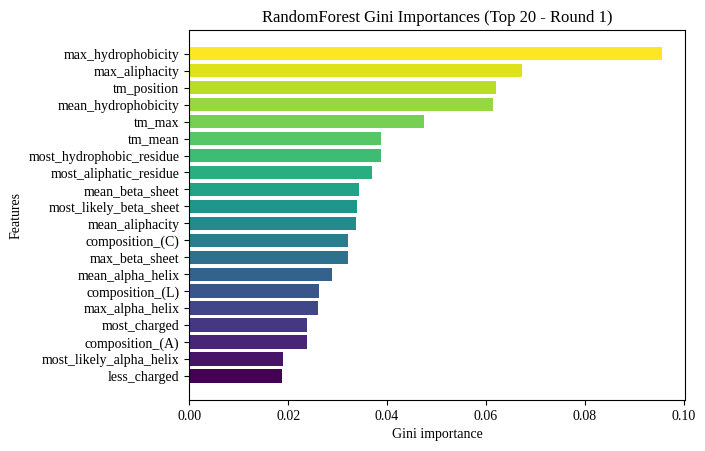


Best 26 features on validation (using baseline SVM hyperparameters): k=30, val_mcc=0.804



<Figure size 640x480 with 0 Axes>

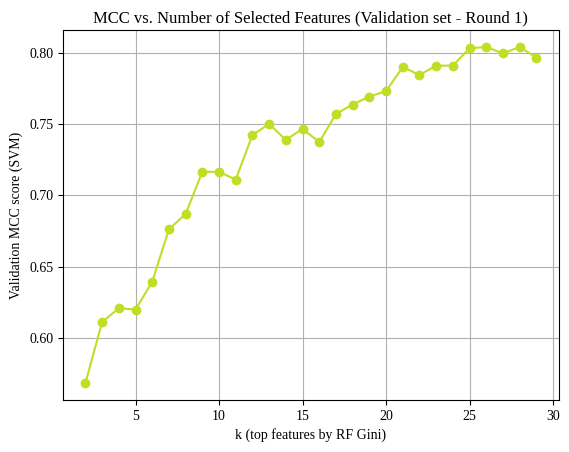

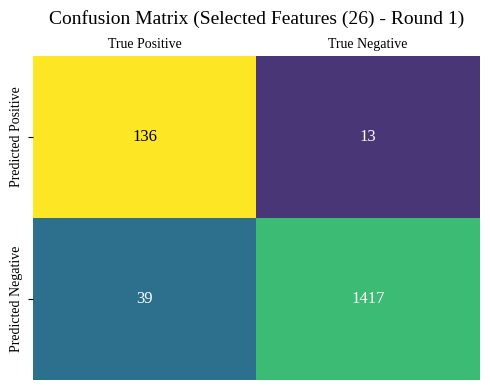

Selected features (26 over the best 30):
0           max_hydrophobicity
1               max_aliphacity
2                  tm_position
3          mean_hydrophobicity
4                       tm_max
5                      tm_mean
6     most_hydrophobic_residue
7       most_aliphatic_residue
8              mean_beta_sheet
9       most_likely_beta_sheet
10             mean_aliphacity
11             composition_(C)
12              max_beta_sheet
13            mean_alpha_helix
14             composition_(L)
15             max_alpha_helix
16                most_charged
17             composition_(A)
18     most_likely_alpha_helix
19                less_charged
20             composition_(R)
21             composition_(P)
22             composition_(I)
23             composition_(V)
24                  min_charge
25             composition_(G)
Name: feature, dtype: object

Best validation MCC score on selected features:  0.804
 with best hyperparameters: {'C': 1, 'gamma': 0.01}

Test MCC score 

<Figure size 500x400 with 0 Axes>

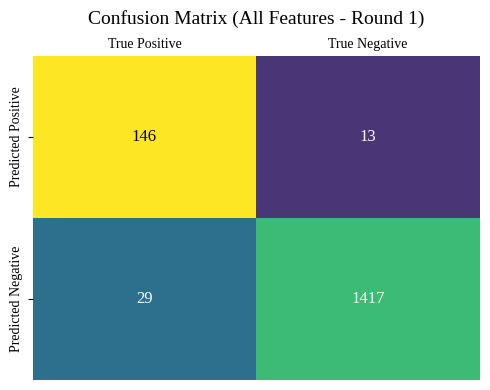

Test MCC score (over all features, baseline tuned on val):  0.861

Selected features Based Model Metrics:
MCC: 0.8249047728223392
Precision: 0.912751677852349
Recall: 0.7771428571428571
Accuracy: 0.967601246105919
F1 Score: 0.8395061728395061

All Features Based Model Metrics:
MCC: 0.8609160804064128
Precision: 0.9182389937106918
Recall: 0.8342857142857143
Accuracy: 0.9738317757009346
F1 Score: 0.874251497005988





============================================= Round 2 =============================================




/tmp/ipython-input-2055609507.py:47: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  Y_train = pd.concat([Y_train, df_training['Class']])


Baseline SVM (over all 39 features) — best validation MCC for round 2: 0.884
 with hyperparameters {'C': 10, 'gamma': 'scale'}



<Figure size 500x400 with 0 Axes>

<Figure size 640x480 with 0 Axes>

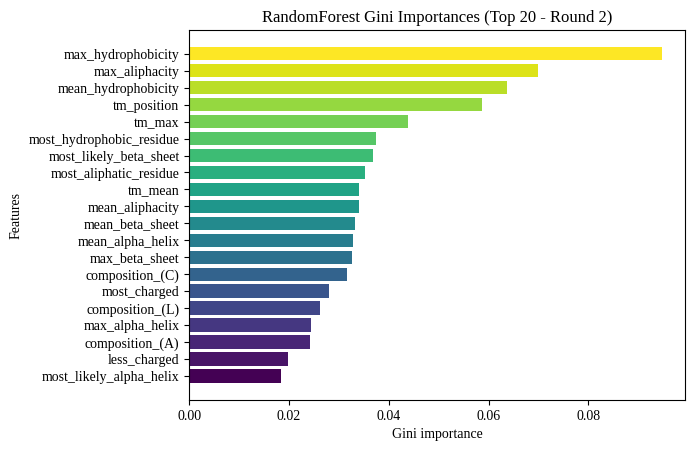


Best 25 features on validation (using baseline SVM hyperparameters): k=30, val_mcc=0.847



<Figure size 640x480 with 0 Axes>

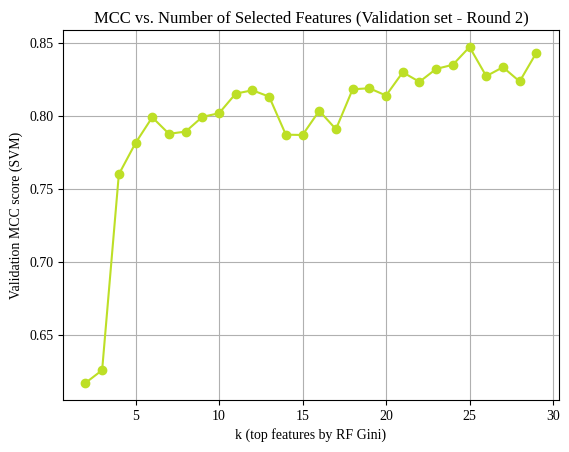

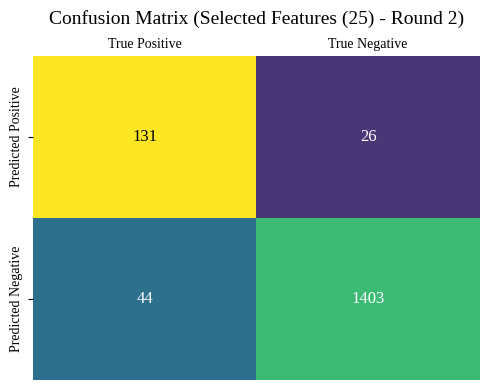

Selected features (25 over the best 30):
0           max_hydrophobicity
1               max_aliphacity
2          mean_hydrophobicity
3                  tm_position
4                       tm_max
5     most_hydrophobic_residue
6       most_likely_beta_sheet
7       most_aliphatic_residue
8                      tm_mean
9              mean_aliphacity
10             mean_beta_sheet
11            mean_alpha_helix
12              max_beta_sheet
13             composition_(C)
14                most_charged
15             composition_(L)
16             max_alpha_helix
17             composition_(A)
18                less_charged
19     most_likely_alpha_helix
20             composition_(S)
21             composition_(I)
22             composition_(R)
23             composition_(P)
24             composition_(V)
Name: feature, dtype: object

Best validation MCC score on selected features:  0.848
 with best hyperparameters: {'C': 10, 'gamma': 0.01}

Test MCC score (selected features, tuned on v

<Figure size 500x400 with 0 Axes>

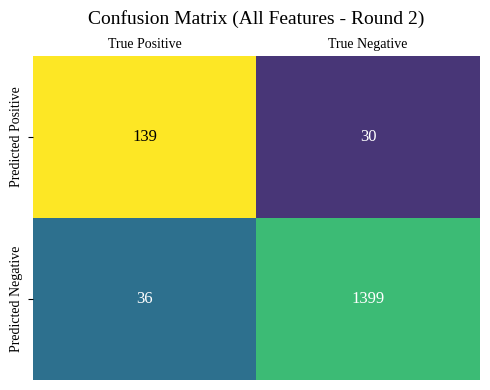

Test MCC score (over all features, baseline tuned on val):  0.785

Selected features Based Model Metrics:
MCC: 0.766298663838751
Precision: 0.8343949044585988
Recall: 0.7485714285714286
Accuracy: 0.956359102244389
F1 Score: 0.7891566265060241

All Features Based Model Metrics:
MCC: 0.785252558559148
Precision: 0.8224852071005917
Recall: 0.7942857142857143
Accuracy: 0.9588528678304239
F1 Score: 0.8081395348837209





============================================= Round 3 =============================================




/tmp/ipython-input-2055609507.py:47: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  Y_train = pd.concat([Y_train, df_training['Class']])


Baseline SVM (over all 39 features) — best validation MCC for round 3: 0.832
 with hyperparameters {'C': 10, 'gamma': 'scale'}



<Figure size 500x400 with 0 Axes>

<Figure size 640x480 with 0 Axes>

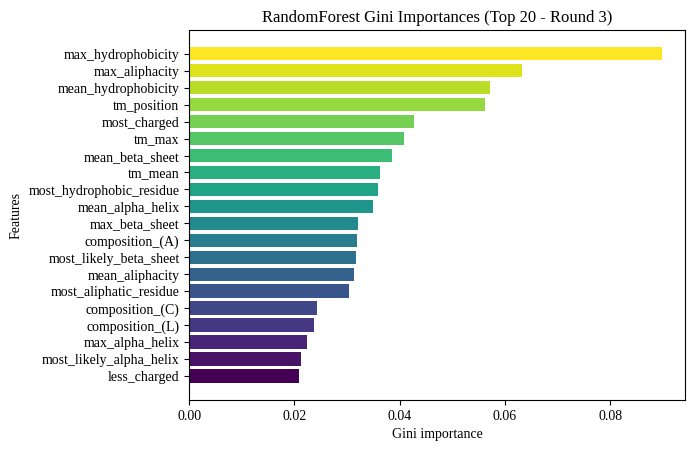


Best 29 features on validation (using baseline SVM hyperparameters): k=30, val_mcc=0.803



<Figure size 640x480 with 0 Axes>

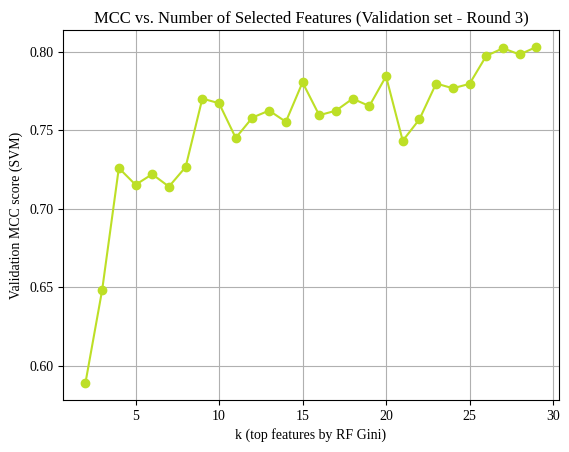

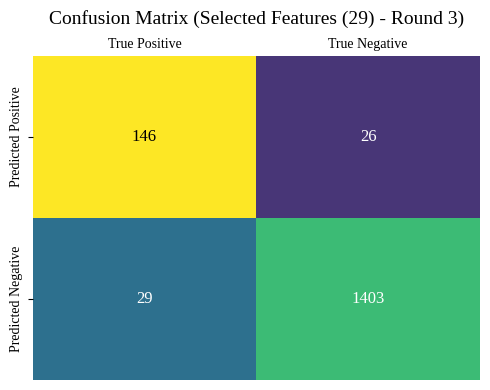

Selected features (29 over the best 30):
0           max_hydrophobicity
1               max_aliphacity
2          mean_hydrophobicity
3                  tm_position
4                 most_charged
5                       tm_max
6              mean_beta_sheet
7                      tm_mean
8     most_hydrophobic_residue
9             mean_alpha_helix
10              max_beta_sheet
11             composition_(A)
12      most_likely_beta_sheet
13             mean_aliphacity
14      most_aliphatic_residue
15             composition_(C)
16             composition_(L)
17             max_alpha_helix
18     most_likely_alpha_helix
19                less_charged
20             composition_(I)
21             composition_(G)
22             composition_(P)
23                  min_charge
24             composition_(S)
25             composition_(V)
26             composition_(F)
27                  max_charge
28             composition_(N)
Name: feature, dtype: object

Best validation MCC score on s

<Figure size 500x400 with 0 Axes>

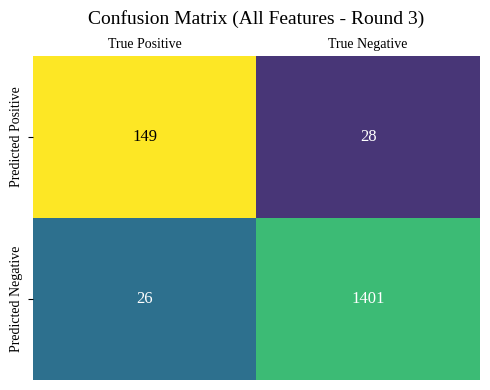

Test MCC score (over all features, baseline tuned on val):  0.828

Selected features Based Model Metrics:
MCC: 0.8223147618088212
Precision: 0.8488372093023255
Recall: 0.8342857142857143
Accuracy: 0.96571072319202
F1 Score: 0.8414985590778098

All Features Based Model Metrics:
MCC: 0.8277008883414263
Precision: 0.8418079096045198
Recall: 0.8514285714285714
Accuracy: 0.9663341645885287
F1 Score: 0.8465909090909091





============================================= Round 4 =============================================




/tmp/ipython-input-2055609507.py:47: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  Y_train = pd.concat([Y_train, df_training['Class']])


Baseline SVM (over all 39 features) — best validation MCC for round 4: 0.841
 with hyperparameters {'C': 10, 'gamma': 0.01}



<Figure size 500x400 with 0 Axes>

<Figure size 640x480 with 0 Axes>

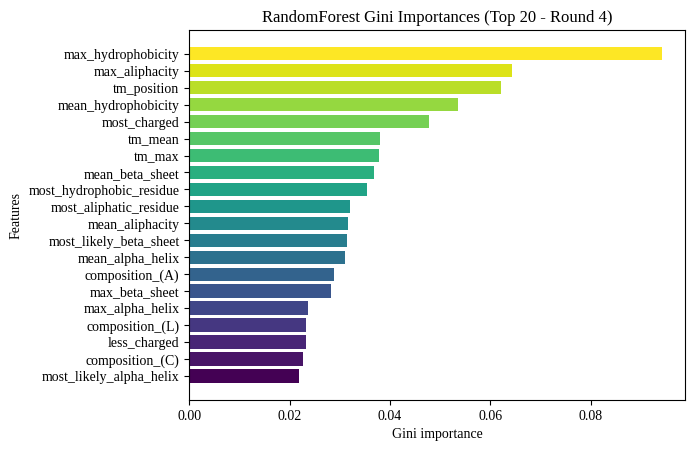


Best 25 features on validation (using baseline SVM hyperparameters): k=30, val_mcc=0.806



<Figure size 640x480 with 0 Axes>

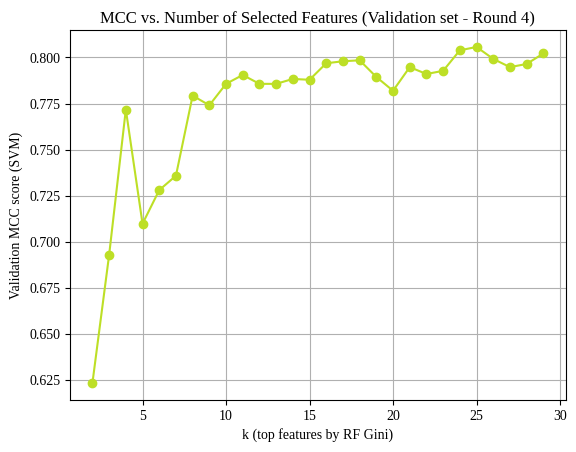

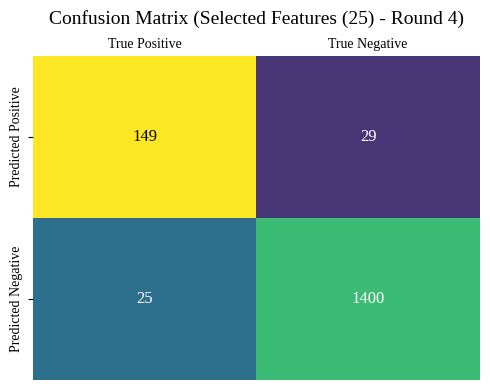

Selected features (25 over the best 30):
0           max_hydrophobicity
1               max_aliphacity
2                  tm_position
3          mean_hydrophobicity
4                 most_charged
5                      tm_mean
6                       tm_max
7              mean_beta_sheet
8     most_hydrophobic_residue
9       most_aliphatic_residue
10             mean_aliphacity
11      most_likely_beta_sheet
12            mean_alpha_helix
13             composition_(A)
14              max_beta_sheet
15             max_alpha_helix
16             composition_(L)
17                less_charged
18             composition_(C)
19     most_likely_alpha_helix
20             composition_(P)
21             composition_(I)
22             composition_(T)
23             composition_(S)
24             composition_(G)
Name: feature, dtype: object

Best validation MCC score on selected features:  0.811
 with best hyperparameters: {'C': 1, 'gamma': 'scale'}

Test MCC score (selected features, tuned on

<Figure size 500x400 with 0 Axes>

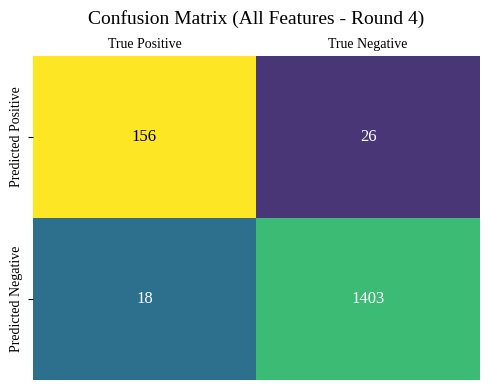

Test MCC score (over all features, baseline tuned on val):  0.861

Selected features Based Model Metrics:
MCC: 0.8277402814280741
Precision: 0.8370786516853933
Recall: 0.8563218390804598
Accuracy: 0.966313162819713
F1 Score: 0.8465909090909091

All Features Based Model Metrics:
MCC: 0.8612498564709852
Precision: 0.8571428571428571
Recall: 0.896551724137931
Accuracy: 0.9725514660012476
F1 Score: 0.8764044943820225





============================================= Round 5 =============================================




/tmp/ipython-input-2055609507.py:47: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  Y_train = pd.concat([Y_train, df_training['Class']])


Baseline SVM (over all 39 features) — best validation MCC for round 5: 0.861
 with hyperparameters {'C': 1, 'gamma': 'scale'}



<Figure size 500x400 with 0 Axes>

<Figure size 640x480 with 0 Axes>

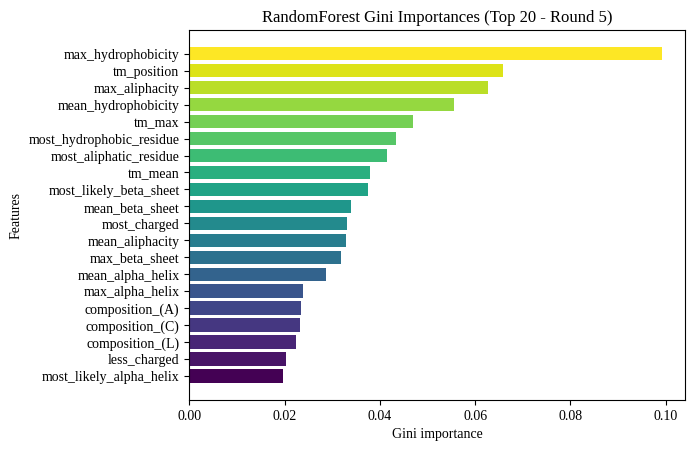


Best 28 features on validation (using baseline SVM hyperparameters): k=30, val_mcc=0.857



<Figure size 640x480 with 0 Axes>

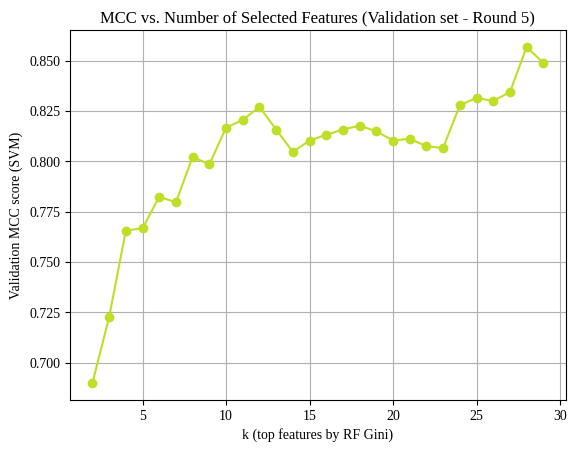

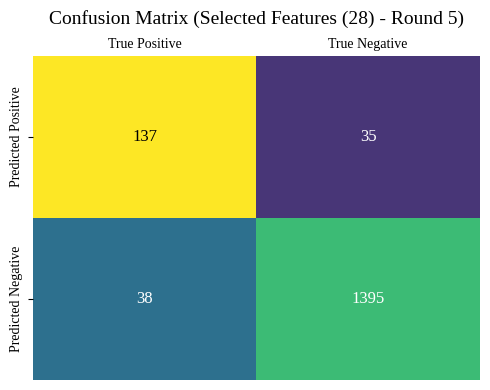

Selected features (28 over the best 30):
0           max_hydrophobicity
1                  tm_position
2               max_aliphacity
3          mean_hydrophobicity
4                       tm_max
5     most_hydrophobic_residue
6       most_aliphatic_residue
7                      tm_mean
8       most_likely_beta_sheet
9              mean_beta_sheet
10                most_charged
11             mean_aliphacity
12              max_beta_sheet
13            mean_alpha_helix
14             max_alpha_helix
15             composition_(A)
16             composition_(C)
17             composition_(L)
18                less_charged
19     most_likely_alpha_helix
20             composition_(P)
21             composition_(I)
22             composition_(S)
23                  min_charge
24             composition_(V)
25             composition_(T)
26             composition_(F)
27             composition_(R)
Name: feature, dtype: object

Best validation MCC score on selected features:  0.857
 with 

<Figure size 500x400 with 0 Axes>

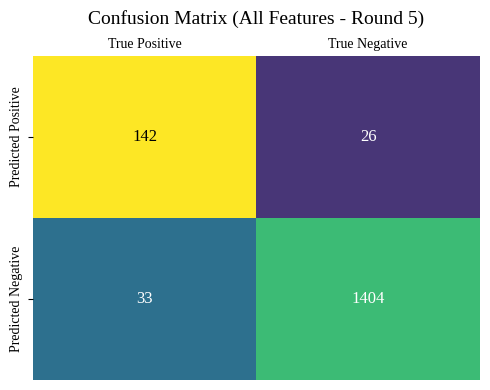

Test MCC score (over all features, baseline tuned on val):  0.808

Selected features Based Model Metrics:
MCC: 0.7641656687317395
Precision: 0.7965116279069767
Recall: 0.7828571428571428
Accuracy: 0.9545171339563863
F1 Score: 0.7896253602305475

All Features Based Model Metrics:
MCC: 0.807629774247421
Precision: 0.8452380952380952
Recall: 0.8114285714285714
Accuracy: 0.9632398753894081
F1 Score: 0.8279883381924198





Combined Confusion Matrix for the 5 folds using selected features:


<Figure size 500x400 with 0 Axes>

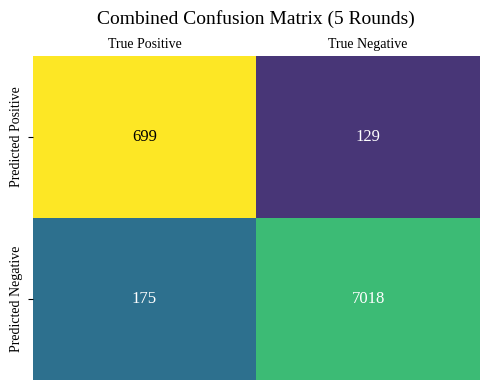


Combined Confusion Matrix for the 5 folds using all features:


<Figure size 500x400 with 0 Axes>

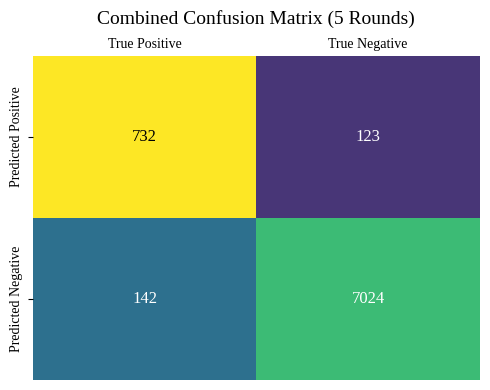

<Figure size 500x400 with 0 Axes>

In [17]:
# X == features
# Y == classes
# y == predictions

# Set the theme globally
mpl.rcParams['font.family'] = 'Liberation Serif'
mpl.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.viridis(np.linspace(0, 1, 10)))

# Importing data
df = pd.read_csv("training_df.tsv", sep = "\t")
# Cross Validation: lists of labels for data splits
training,validation,testing = cross_val(5)

feature_names = np.array([f"composition_({residue})" for residue in "AQLSREKTNGMWDHFYCIPV"] + # 20 aa composition
 ["mean_hydrophobicity", "max_hydrophobicity", "most_hydrophobic_residue",
  "mean_aliphacity", "max_aliphacity", "most_aliphatic_residue", # 6 hydrophobicity and aliphacity
  "tm_mean", "tm_max", "tm_position", # 3 tm propensity features
  "mean_alpha_helix", "max_alpha_helix", "most_likely_alpha_helix",
  "mean_beta_sheet", "max_beta_sheet", "most_likely_beta_sheet", # 6 accounting for SSE
  "max_charge", "most_charged", "min_charge", "less_charged" # 4 accounting for charge
  ])

# Lists for hyperparameters grid search
C_grid = [0.1, 1, 10, 100]
gamma_grid = ["scale", 0.01, 0.1, 1.0]

# Initializing confusion matrices
cm_sel = []
cm_all = []

# Cross Validation
for i in range(len(validation)):
    print(f"============================================= Round {i+1} =============================================")
    print("")
    print("")

    # Selecting sequence fragments for training, validation and testing data folds
    training_sequences = pd.Series([], dtype = object)
    Y_train = pd.Series([], dtype = object)
    validation_sequences = df[df['Label'] == validation[i]]['Frag_90']
    Y_val = df[df['Label'] == validation[i]]['Class']
    testing_sequences = df[df['Label'] == testing[i]]['Frag_90']
    Y_test = df[df['Label'] == testing[i]]['Class']
    for el in training[i]:
            df_training = df[df['Label'] == el]
            training_sequences = pd.concat([training_sequences, df_training['Frag_90']])
            Y_train = pd.concat([Y_train, df_training['Class']])

    # Feature Extraction
    X_train = extract_features(training_sequences)
    X_val = extract_features(validation_sequences)
    X_test = extract_features(testing_sequences)

    # Hyperparameters grid search over the validation set
    best_mcc , mcc_params = grid_search(C_grid, gamma_grid, X_train, Y_train, X_val, Y_val)
    print(f"Baseline SVM (over all {len(X_train[0])} features) — best validation MCC for round "+str(validation[i])+": "
          f"{best_mcc:.3f}\n with hyperparameters {mcc_params}")
    print("")

    # RF classifier for feature Gini Importances
    rf = RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1,
                                class_weight={0: 9, 1: 1}) # ADDRESSING CLASS UNBALANCE
    rf.fit(X_train, Y_train)  # fit only on TRAIN
    gini_imp = pd.Series(rf.feature_importances_, index = feature_names).sort_values(ascending=False)
    gini_df = gini_imp.reset_index()
    gini_df.columns = ["feature", "importance"]
    gini_df.to_csv("Features_gini_"+str(validation[i])+".tsv", sep = "\t", index = False, header = True)

    # Plot top 20

    plt.figure()
    colors = plt.cm.viridis(np.linspace(0, 1, 20))
    plt.barh(gini_df["feature"].head(20)[::-1],gini_df["importance"].head(20)[::-1],color=colors)
    plt.xlabel("Gini importance")
    plt.ylabel("Features")
    plt.title(f"RandomForest Gini Importances (Top 20 - Round {i+1})")
    plt.savefig(f"Top_Features_round{i+1}.png", dpi = 1000, format = "png", bbox_inches="tight", pad_inches = 0.2)
    plt.clf()
    plt.figure()
    colors = plt.cm.viridis(np.linspace(0, 1, 20))
    plt.barh(gini_df["feature"].head(20)[::-1],gini_df["importance"].head(20)[::-1],color=colors)
    plt.xlabel("Gini importance")
    plt.ylabel("Features")
    plt.title(f"RandomForest Gini Importances (Top 20 - Round {i+1})")
    plt.show()
    print("")

    # Feature selection
    ks = list(range(2, min(30, X_train.shape[1]+1)))  # keep it small for speed/clarity
    mcc_curve = []

    for k in ks:
        subset = gini_df["feature"].head(k).tolist()
        mcc_k = mcc_subset(mcc_params["C"], mcc_params["gamma"], subset)
        mcc_curve.append(mcc_k)

    mcc_idx = int(np.argmax(mcc_curve))
    mcc_ks = ks[mcc_idx]
    print(f"Best {mcc_idx+2} features on validation (using baseline SVM hyperparameters): k={len(ks)+2}, val_mcc={mcc_curve[mcc_idx]:.3f}")
    print("")

    plt.figure()
    plt.plot(ks, mcc_curve, marker="o", color=plt.cm.viridis(0.9))
    plt.xlabel("k (top features by RF Gini)")
    plt.ylabel("Validation MCC score (SVM)")
    plt.title(f"MCC vs. Number of Selected Features (Validation set - Round {i+1})")
    plt.grid(True)
    plt.savefig(f"MCC_vs_Val_round{i+1}.png", dpi = 1000, format = "png", bbox_inches="tight", pad_inches = 0.2)
    plt.clf()
    plt.figure()
    plt.plot(ks, mcc_curve, marker="o", color=plt.cm.viridis(0.9))
    plt.xlabel("k (top features by RF Gini)")
    plt.ylabel("Validation MCC score (SVM)")
    plt.title(f"MCC vs. Number of Selected Features (Validation set - Round {i+1})")
    plt.grid(True)
    plt.show()
    print("")

    # Use the best k from the validation curve
    feature_subset = gini_df["feature"].head(mcc_ks).tolist()
    mcc_idx = [np.where(feature_names == f)[0][0] for f in feature_subset]

    Xtr = X_train[:, mcc_idx]
    Xva = X_val[:, mcc_idx]
    Xte = X_test[:, mcc_idx]

    # Grid search restricted to the selected features
    mcc_sel, mcc_selp = grid_search(C_grid, gamma_grid, Xtr, Y_train, Xva, Y_val)

    # Train final model on TRAIN+VAL with best params (optional) or just TRAIN; here we keep TRAIN only as per your outline
    final_model = svm_pipeline(mcc_selp["C"], mcc_selp["gamma"])
    final_model = final_model.fit(Xtr, Y_train)
    pickle.dump(final_model, gzip.open(f"SVM(selected)_mcc_{i+1}.pkl.gz","w"))
    predmcc_test = final_model.predict(Xte)
    test_mcc = matthews_corrcoef(Y_test, predmcc_test)

    cm_sel.append(confusion_matrix(Y_test, predmcc_test))

    plot_confusion_matrix_custom(Y_test, predmcc_test, validation[i], f"Selected Features ({len(mcc_idx)})")
    plt.show()
    plot_confusion_matrix_custom(Y_test, predmcc_test, validation[i], f"Selected Features ({len(mcc_idx)})")
    plt.savefig(f"CM_selected_{validation[i]}.png", dpi=1000, format="png", bbox_inches="tight", pad_inches=0.2)
    plt.clf()

    metrics_mcc_values = [test_mcc, precision_score(Y_test, predmcc_test), recall_score(Y_test, predmcc_test), accuracy_score(Y_test, predmcc_test), f1_score(Y_test, predmcc_test)]
    pickle.dump(metrics_mcc_values, gzip.open(f"Metrics(sel)_mcc_{i+1}.pkl.gz","w"))

    print(f"Selected features ({len(mcc_idx)} over the best {len(ks)+2}):")
    print(gini_df['feature'].iloc[:len(mcc_idx)])
    print("")
    print("Best validation MCC score on selected features: ", f"{mcc_sel:.3f}\n", "with best hyperparameters:", mcc_selp)
    print("")
    print("Test MCC score (selected features, tuned on val): ", f"{test_mcc:.3f}")
    print("")

    # For comparison: test accuracy with all features using baseline best params

    baseline_model = svm_pipeline(mcc_params["C"], mcc_params["gamma"])
    baseline_model.fit(X_train, Y_train)
    pickle.dump(baseline_model, gzip.open(f"SVM(all)_mcc_{i+1}.pkl.gz","w"))
    baseline_predtest = baseline_model.predict(X_test)
    test_mcc_all = matthews_corrcoef(Y_test, baseline_predtest)

    cm_all.append(confusion_matrix(Y_test, baseline_predtest))

    plot_confusion_matrix_custom(Y_test, baseline_predtest, validation[i], "All Features")
    plt.show()
    plot_confusion_matrix_custom(Y_test, baseline_predtest, validation[i], "All Features")
    plt.savefig(f"CM_all_{validation[i]}.png", dpi=1000, format="png", bbox_inches="tight", pad_inches=0.2)
    plt.clf()

    metrics_mcc_all_values = [test_mcc_all, precision_score(Y_test, baseline_predtest), recall_score(Y_test, baseline_predtest), accuracy_score(Y_test, baseline_predtest), f1_score(Y_test, baseline_predtest)]
    pickle.dump(metrics_mcc_all_values, gzip.open(f"Metrics(all)_mcc_{i+1}.pkl.gz","w"))



    print("Test MCC score (over all features, baseline tuned on val): ", f"{test_mcc_all:.3f}")
    print("")
    print("Selected features Based Model Metrics:")
    mets = ["MCC", "Precision", "Recall", "Accuracy", "F1 Score"]
    for j in range(len(metrics_mcc_values)):
      print(mets[j]+": "+str(metrics_mcc_values[j]))
    print("")
    print("All Features Based Model Metrics:")
    for j in range(len(metrics_mcc_all_values)):
      print(mets[j]+": "+str(metrics_mcc_all_values[j]))
    print("")
    print("")
    print("")
    print("")
    print("")

print("Combined Confusion Matrix for the 5 folds using selected features:")
plot_combined_confusion_matrix(cm_sel, len(cm_sel))
plt.show()

plot_combined_confusion_matrix(cm_sel, len(cm_sel))
plt.savefig("CM_sel_combined.png", dpi = 1000, format = "png", bbox_inches = "tight", pad_inches = 0.2)
plt.clf()
print("")
print("Combined Confusion Matrix for the 5 folds using all features:")
plot_combined_confusion_matrix(cm_all, len(cm_all))
plt.show()
plot_combined_confusion_matrix(cm_all, len(cm_all))
plt.savefig("CM_all_combined.png", dpi = 1000, format = "png", bbox_inches = "tight", pad_inches = 0.2)
plt.clf()

In [19]:
!zip -r output.zip /content/
from google.colab import files
files.download("output.zip")

  adding: content/ (stored 0%)
  adding: content/.config/ (stored 0%)
  adding: content/.config/active_config (stored 0%)
  adding: content/.config/config_sentinel (stored 0%)
  adding: content/.config/logs/ (stored 0%)
  adding: content/.config/logs/2025.11.12/ (stored 0%)
  adding: content/.config/logs/2025.11.12/14.30.35.902193.log (deflated 56%)
  adding: content/.config/logs/2025.11.12/14.30.26.280314.log (deflated 58%)
  adding: content/.config/logs/2025.11.12/14.30.15.789373.log (deflated 58%)
  adding: content/.config/logs/2025.11.12/14.30.35.156140.log (deflated 57%)
  adding: content/.config/logs/2025.11.12/14.30.24.701531.log (deflated 86%)
  adding: content/.config/logs/2025.11.12/14.29.51.386235.log (deflated 92%)
  adding: content/.config/.last_survey_prompt.yaml (stored 0%)
  adding: content/.config/default_configs.db (deflated 98%)
  adding: content/.config/.last_opt_in_prompt.yaml (stored 0%)
  adding: content/.config/gce (stored 0%)
  adding: content/.config/hidden_gc

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>